# Theme-agnostic piece detection (F + combined steps)

Implements **edge/shape matching (F)** and combines it with:
- **Per-square normalization** (zero-mean, unit-variance)
- **Occupancy-first** (empty vs occupied using one or two empty templates)
- **Two empty templates** (200_light, 200_dark) when available

Compare three modes: **normalized only**, **edge only**, and **combined** (normalized + edge) to see impact on accuracy.

## 1. Setup

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

from src.agent.vision_template import (
    find_board_corners_contour,
    find_board_corners_edges,
    load_templates,
    image_to_fen_template,
    patch_to_edge_map,
    SQUARE_SIZE,
    BOARD_SIZE,
)
from src.agent.vision_template import (
    _warp_board,
    _extract_squares,
    _match_square_to_templates,
    _squares_to_fen,
)

%matplotlib inline

## 2. Configuration

In [9]:
IMAGE_PATH = project_root / "sample_screenshot.png"
METHOD = "contour"
TEMPLATES_DIR = project_root / "templates"

EMPTY_THRESHOLD = 0.95
PIECE_THRESHOLD = 0.45
NORMALIZE = True

# Combined mode: weight for edge score (0 = normalized only, 1 = edge only, 0.5 = half and half)
EDGE_WEIGHT_COMBINED = 0.5
EDGE_METHOD = "gradient"  # or "canny"

## 3. Load screenshot and detect board

In [10]:
img = np.array(Image.open(IMAGE_PATH).convert("RGB"))
print(f"Image shape: {img.shape}")

if METHOD == "contour":
    corners = find_board_corners_contour(img)
else:
    corners = find_board_corners_edges(img)

if corners is None:
    raise RuntimeError("Board not detected. Try the other method or another screenshot.")

warped = _warp_board(img, corners)
squares = _extract_squares(warped)
print(f"Extracted {len(squares)} squares, each {SQUARE_SIZE}×{SQUARE_SIZE}")

Image shape: (1076, 1912, 3)
Extracted 64 squares, each 50×50


## 4. Load templates (empty + pieces)

In [11]:
templates = load_templates(TEMPLATES_DIR, target_size=SQUARE_SIZE)
empty_templates = [(t, m, c) for t, m, c in templates if c == "."]
piece_templates = [(t, m, c) for t, m, c in templates if c != "."]

print(f"Loaded {len(templates)} templates: {len(empty_templates)} empty, {len(piece_templates)} pieces")
if empty_templates:
    print("  (Using two empty templates 200_light/200_dark when present for better occupancy.)")

Loaded 14 templates: 2 empty, 12 pieces
  (Using two empty templates 200_light/200_dark when present for better occupancy.)


## 5. Edge map preview (F: shape-based representation)

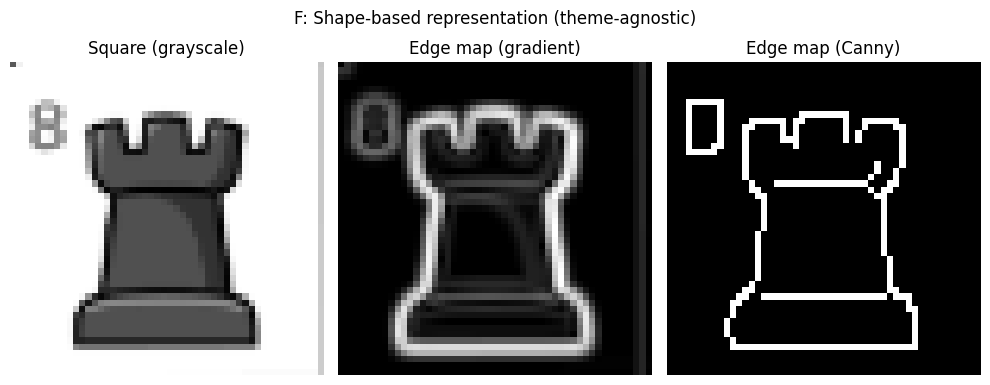

In [12]:
# Show one square as grayscale vs gradient edge map vs Canny
sq = squares[0]
if sq.ndim == 3:
    gray = cv2.cvtColor(cv2.cvtColor(sq, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2GRAY)
else:
    gray = sq

edge_grad = patch_to_edge_map(gray, method="gradient")
edge_canny = patch_to_edge_map(gray, method="canny")

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Square (grayscale)")
axes[0].axis("off")
axes[1].imshow(edge_grad, cmap="gray")
axes[1].set_title("Edge map (gradient)")
axes[1].axis("off")
axes[2].imshow(edge_canny, cmap="gray")
axes[2].set_title("Edge map (Canny)")
axes[2].axis("off")
plt.suptitle("F: Shape-based representation (theme-agnostic)")
plt.tight_layout()
plt.show()

## 6. Run three matching modes

In [13]:
def run_mode(squares, empty_templates, piece_templates, use_edges, edge_weight, label):
    chars = [
        _match_square_to_templates(
            sq,
            empty_templates,
            piece_templates,
            EMPTY_THRESHOLD,
            PIECE_THRESHOLD,
            normalize=NORMALIZE,
            use_edges=use_edges,
            edge_weight=edge_weight,
            edge_method=EDGE_METHOD,
        )
        for sq in squares
    ]
    return _squares_to_fen(chars), chars

# Normalized only (baseline)
fen_norm, chars_norm = run_mode(
    squares, empty_templates, piece_templates,
    use_edges=False, edge_weight=0.0, label="normalized"
)
# Edge only (F)
fen_edge, chars_edge = run_mode(
    squares, empty_templates, piece_templates,
    use_edges=True, edge_weight=1.0, label="edge"
)
# Combined (normalized + edge)
fen_combined, chars_combined = run_mode(
    squares, empty_templates, piece_templates,
    use_edges=True, edge_weight=EDGE_WEIGHT_COMBINED, label="combined"
)

print("FEN (normalized only):", fen_norm)
print("FEN (edge only, F):   ", fen_edge)
print("FEN (combined):       ", fen_combined)

FEN (normalized only): 8/8/8/8/8/8/8/8
FEN (edge only, F):    8/8/8/8/8/8/8/8
FEN (combined):        8/8/8/8/8/8/8/8


## 7. Visual comparison: 8×8 boards

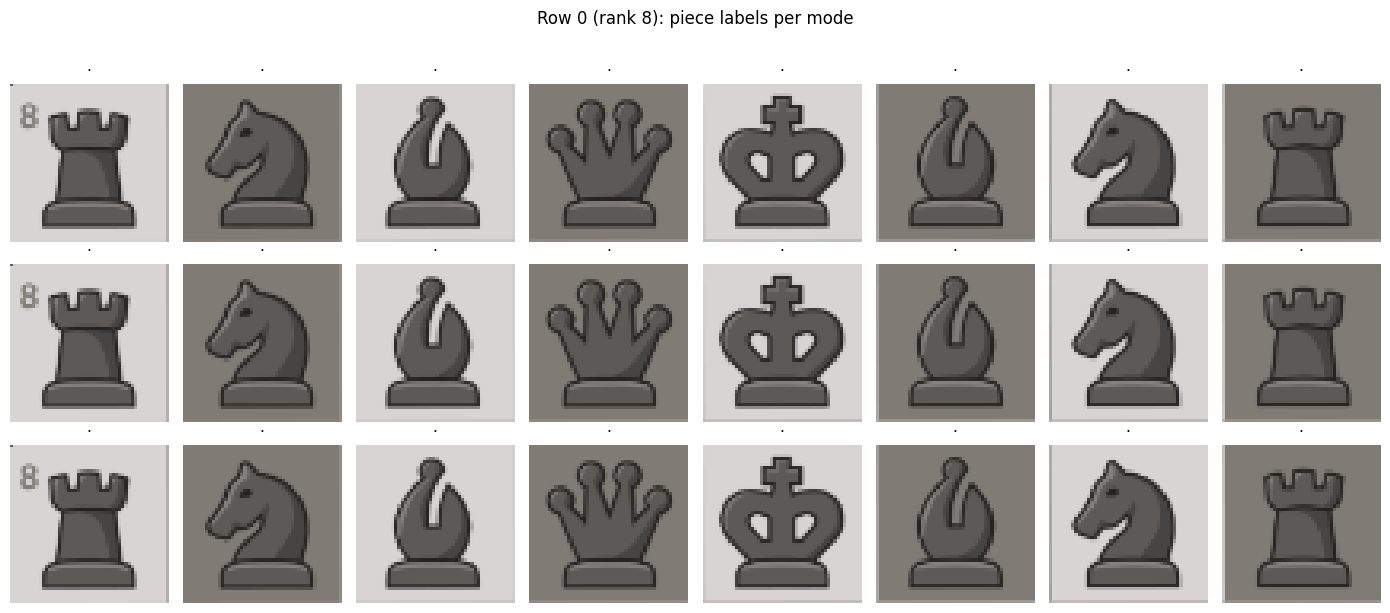

In [14]:
def draw_board(axes, squares, chars, title):
    for row in range(8):
        for col in range(8):
            idx = row * 8 + col
            axes[row, col].imshow(squares[idx])
            axes[row, col].set_title(
                chars[idx] if chars[idx] != "." else "·",
                fontsize=12,
            )
            axes[row, col].axis("off")
    axes[0, 4].set_title(title, fontsize=14)

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        axes[0, col].imshow(squares[idx]) if row == 0 else None
        axes[0, col].axis("off")
        if row == 0:
            axes[0, col].set_title(chars_norm[idx] if chars_norm[idx] != "." else "·", fontsize=11)
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        axes[1, col].imshow(squares[idx]) if row == 0 else None
        if row == 0:
            axes[1, col].axis("off")
            axes[1, col].set_title(chars_edge[idx] if chars_edge[idx] != "." else "·", fontsize=11)
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        axes[2, col].imshow(squares[idx]) if row == 0 else None
        if row == 0:
            axes[2, col].axis("off")
            axes[2, col].set_title(chars_combined[idx] if chars_combined[idx] != "." else "·", fontsize=11)

axes[0, 0].set_ylabel("Normalized", fontsize=11)
axes[1, 0].set_ylabel("Edge only (F)", fontsize=11)
axes[2, 0].set_ylabel("Combined", fontsize=11)
plt.suptitle("Row 0 (rank 8): piece labels per mode", y=1.02)
plt.tight_layout()
plt.show()

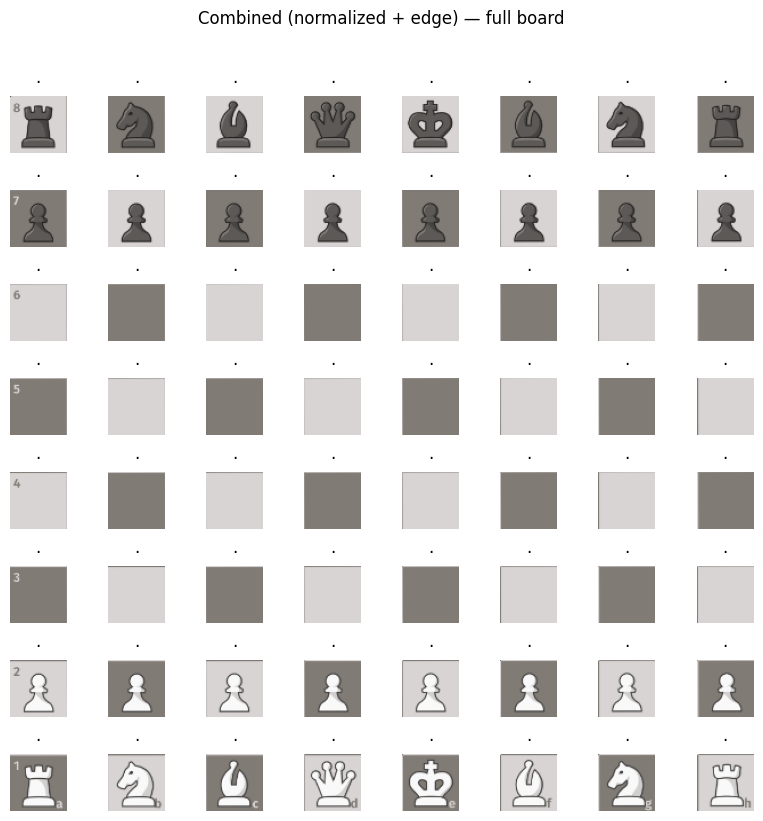

Final FEN (combined): 8/8/8/8/8/8/8/8


In [15]:
# Full 8×8 grid for combined (recommended)
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for row in range(8):
    for col in range(8):
        idx = row * 8 + col
        axes[row, col].imshow(squares[idx])
        axes[row, col].set_title(
            chars_combined[idx] if chars_combined[idx] != "." else "·",
            fontsize=12,
        )
        axes[row, col].axis("off")
plt.suptitle("Combined (normalized + edge) — full board", y=1.02)
plt.tight_layout()
plt.show()
print("Final FEN (combined):", fen_combined)

## 8. One-shot API with edge matching

In [ ]:
fen_api = image_to_fen_template(
    img,
    TEMPLATES_DIR,
    method=METHOD,
    empty_threshold=EMPTY_THRESHOLD,
    piece_threshold=PIECE_THRESHOLD,
    normalize=NORMALIZE,
    use_edges=True,
    edge_weight=EDGE_WEIGHT_COMBINED,
    edge_method=EDGE_METHOD,
)
print("image_to_fen_template(..., use_edges=True, edge_weight=0.5) ->", fen_api)